In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import data_utils_clean
from scipy.stats import chi2_contingency,f_oneway,jarque_bera,probplot
import plotly.express as px

In [ ]:
#load the data
df  = pd.read_csv('swiggy.csv')
df.sample(30)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
37255,0x440e,SURRES09DEL03,36,4.5,21.175975,72.795503,21.235975,72.855503,26-03-2022,17:30:00,17:45:00,conditions Sandstorms,Medium,2,Snack,scooter,1,No,Metropolitian,(min) 25
10942,0x6f4f,COIMBRES04DEL01,30,4.5,11.024839,77.007003,11.134839,77.117003,10-03-2022,17:35:00,17:40:00,conditions Stormy,Medium,1,Drinks,motorcycle,1,No,Metropolitian,(min) 27
39818,0xbdb9,VADRES11DEL01,23,4.7,22.308096,73.167753,22.378096,73.237753,04-04-2022,19:40:00,19:50:00,conditions Sunny,Jam,1,Buffet,scooter,1,No,Urban,(min) 23
390,0x8f8,VADRES18DEL01,NaN,NaN,0.000000,0.000000,0.070000,0.070000,10-03-2022,NaN,17:55:00,conditions Sunny,Medium,0,Snack,motorcycle,0,No,Urban,(min) 17
34251,0x3cae,VADRES04DEL02,27,4.8,0.000000,0.000000,0.080000,0.080000,02-04-2022,18:45:00,18:55:00,conditions Fog,Medium,2,Buffet,motorcycle,0,No,Urban,(min) 32
18590,0x9a11,JAPRES13DEL03,30,4.9,26.846156,75.802300,26.936156,75.892300,20-03-2022,17:50:00,18:00:00,conditions Stormy,Medium,2,Buffet,scooter,1,No,Metropolitian,(min) 25
40796,0x9c70,JAPRES07DEL02,35,4.7,26.766536,75.837333,26.846536,75.917333,18-03-2022,17:45:00,17:50:00,conditions Fog,Medium,0,Drinks,motorcycle,2,No,Metropolitian,(min) 42
4939,0x5563,MYSRES16DEL01,31,4.2,12.316967,76.603067,12.386967,76.673067,12-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,0,Buffet,motorcycle,1,No,Semi-Urban,(min) 53
43780,0xad09,CHENRES17DEL03,29,4.6,13.045479,80.233110,13.135479,80.323110,08-03-2022,22:55:00,23:00:00,conditions Stormy,Low,0,Drinks,motorcycle,1,No,Metropolitian,(min) 19
25811,0x8cd7,HYDRES08DEL03,21,4.9,17.438263,78.397865,17.468263,78.427865,17-03-2022,23:00:00,23:05:00,conditions Cloudy,Low,1,Meal,scooter,0,No,Urban,(min) 15


In [ ]:
#clean the data using the utile file
data_utils_clean.perform_data_cleaning(data=df)

In [ ]:
df_final = pd.read_csv('swiggy_cleaned.csv')

In [ ]:
#check for missing values in data
df_final.isnull().sum()

,0
rider_id,0
age,1854
ratings,1908
restaurant_latitude,3630
restaurant_longitude,3630
delivery_latitude,3630
delivery_longitude,3630
order_date,0
weather,525
traffic,510


In [ ]:
#number of rows in the data that have missing values
missing_rows = (
    df_final.isnull().any(axis=1).sum()
)
print(f'there are {missing_rows} rows with missing values in the data')
print(f'it accounts for {(missing_rows/df_final.shape[0])*100:.2f}% of the data')

there are 7807 rows with missing values in the data
it accounts for 17.16% of the data


In [ ]:
#check for duplicate rows in data
df_final.duplicated().sum()

np.int64(0)

there are no duplicate rows in the data and none were created by our dta cleaning step

In [ ]:
#data types of features
df_final.dtypes

,0
rider_id,object
age,float64
ratings,float64
restaurant_latitude,float64
restaurant_longitude,float64
delivery_latitude,float64
delivery_longitude,float64
order_date,object
weather,object
traffic,object


In [ ]:
#numerical and categorical columns
num_cols = df_final.columns[[1,2,3,4,5,6,16,22,25]].tolist()
cat_cols = [col for col in df_final.columns.tolist() if col not in num_cols]

print(f'There are {len(num_cols)} numerical columns and {len(cat_cols)} categorical columns in the data')

There are 9 numerical columns and 18 categorical columns in the data


In [ ]:
num_cols

['age',
 'ratings',
 'restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'time_taken',
 'pickup_time_minutes',
 'distance']

In [ ]:
cat_cols

['rider_id',
 'order_date',
 'weather',
 'traffic',
 'vehicle_condition',
 'type_of_order',
 'type_of_vehicle',
 'multiple_deliveries',
 'festival',
 'city_type',
 'city_name',
 'order_day',
 'order_month',
 'order_day_of_week',
 'is_weekend',
 'order_time_hour',
 'order_time_of_day',
 'distance_type']

In [ ]:
df_final[num_cols].describe()

,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,time_taken,pickup_time_minutes,distance
count,43648.000000,43594.000000,41872.000000,41872.000000,41872.000000,41872.000000,45502.000000,43862.000000,41872.000000
mean,29.555008,4.635287,18.913696,76.921664,18.977356,76.985325,26.297591,9.989399,9.719296
std,5.761482,0.313827,5.467265,3.503107,5.469056,3.503260,9.386419,4.087516,5.602890
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,10.000000,5.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.065996,73.940327,19.000000,5.000000,4.657655
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.662620,26.000000,10.000000,9.193014
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,32.000000,15.000000,13.680920
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,54.000000,15.000000,20.969489


In [ ]:
#statistical summary of categorical columns
(
    df_final
    .assign(**{
        col:df_final[col].astype("object")
        for col in cat_cols
    })
    .describe(include="object")
    .T
)

,count,unique,top,freq
rider_id,45502,1320,PUNERES01DEL01,67
order_date,45502,44,2022-03-15,1190
weather,44977,6,fog,7654
traffic,44992,4,low,15477
vehicle_condition,45502,4,2,15034
type_of_order,45502,4,snack,11512
type_of_vehicle,45502,4,motorcycle,26427
multiple_deliveries,44509.0,4.0,1.0,28109.0
festival,45274,2,no,44380
city_type,44304,3,metropolitian,34029


missing value analysis


In [ ]:
!pip install missingno

In [ ]:
import missingno as msno

<Axes: >

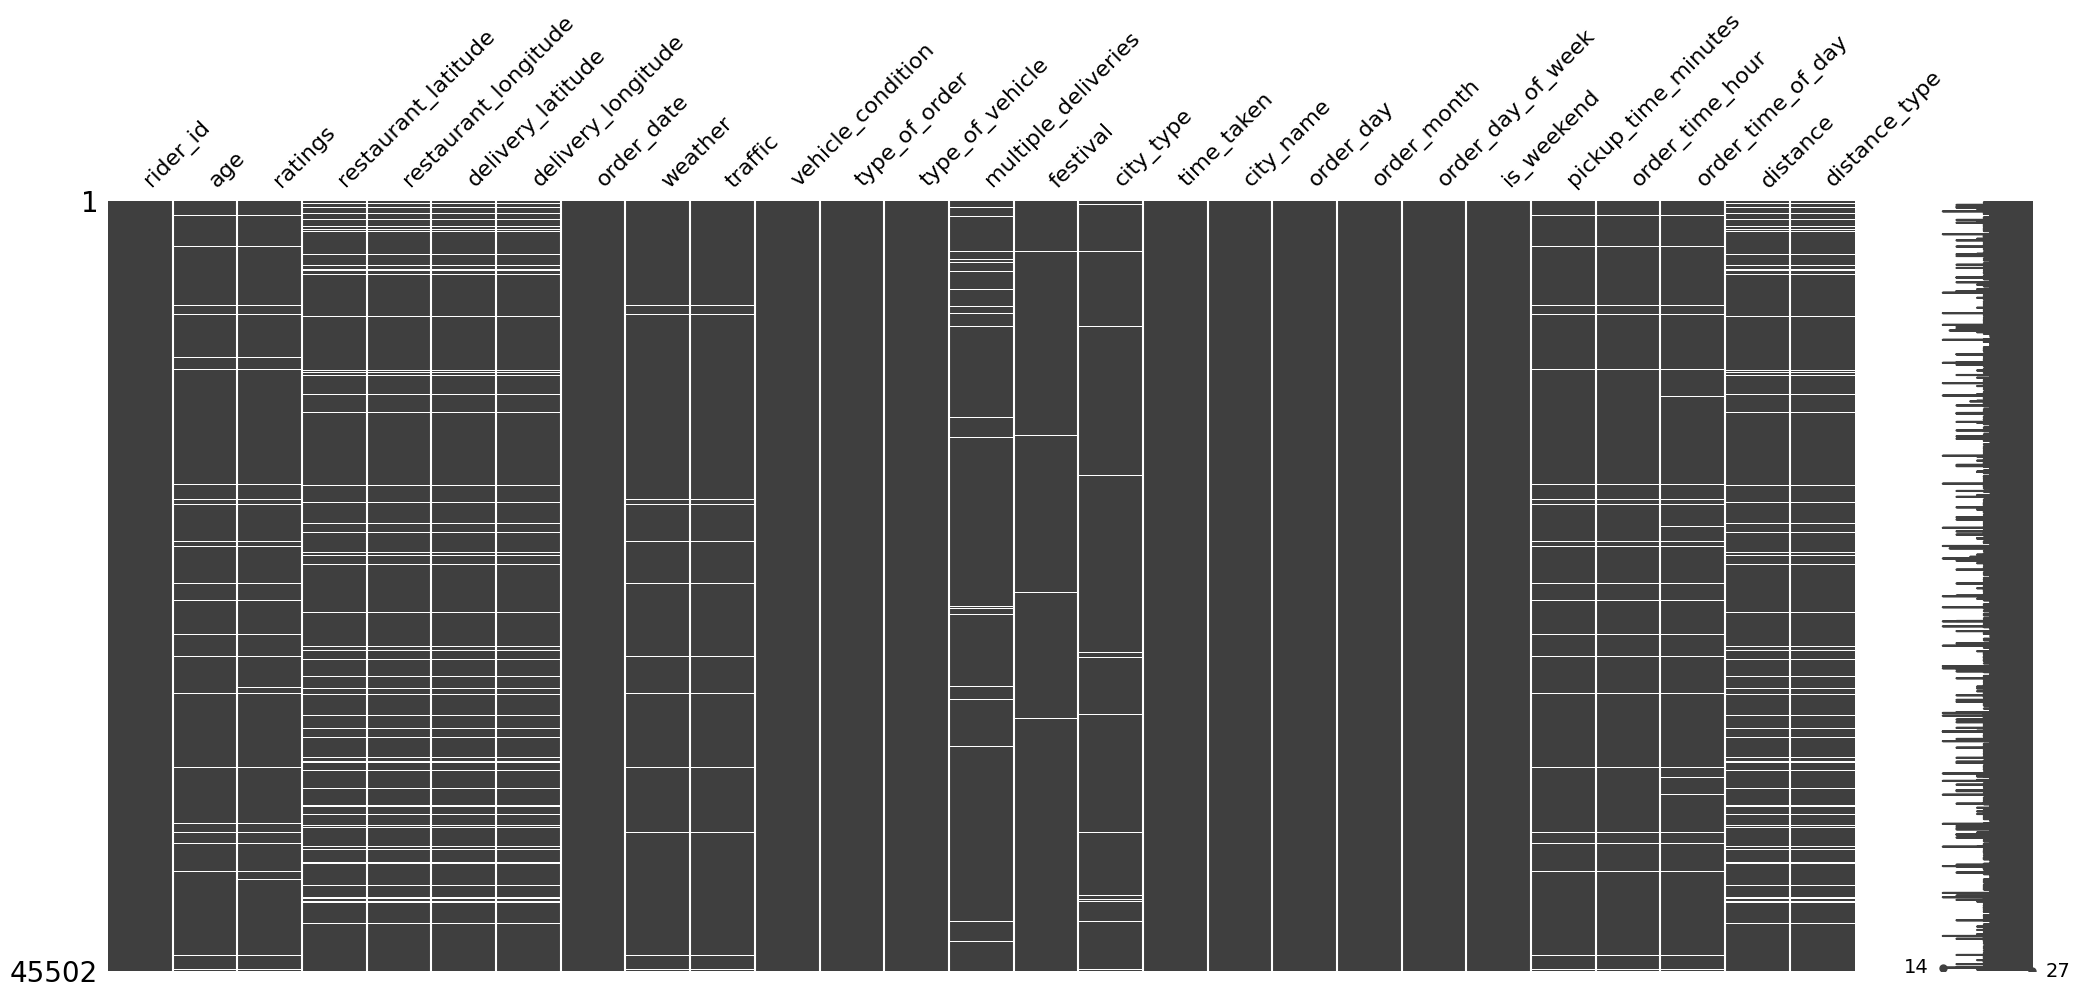

In [ ]:
#matrix plot
msno.matrix(df_final)

<Axes: >

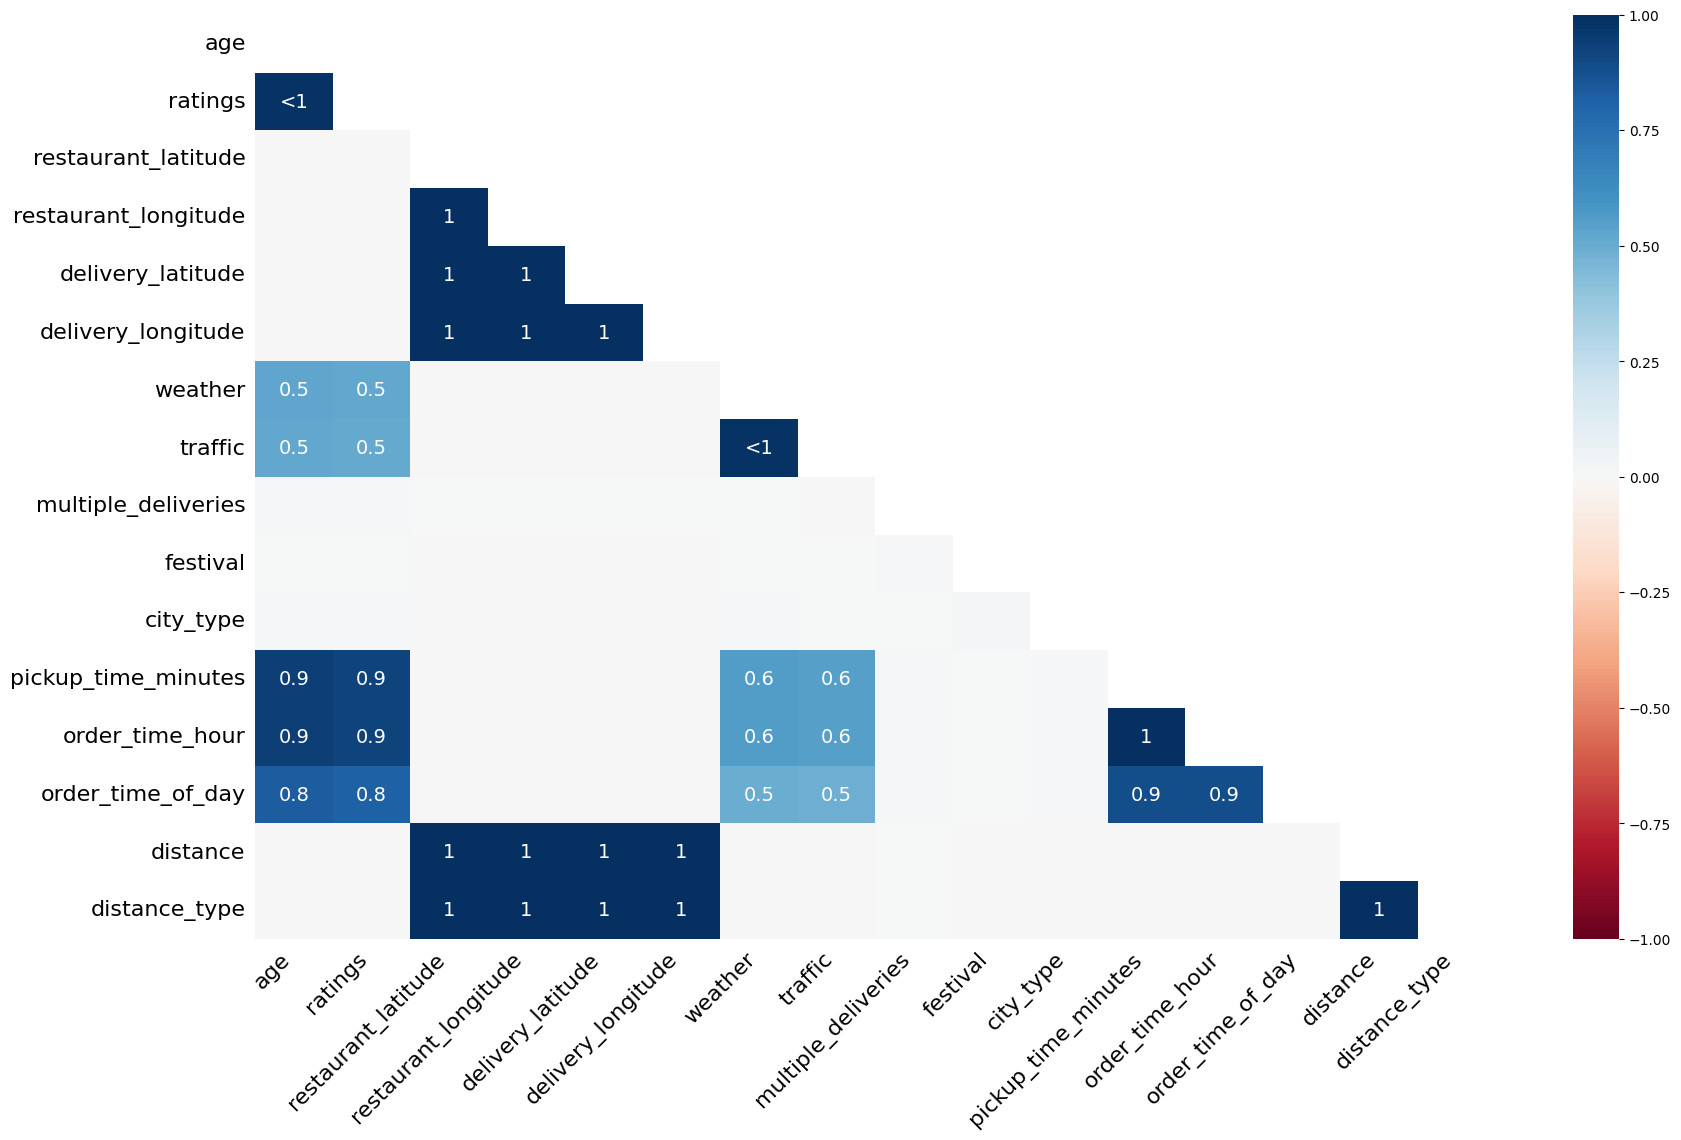

In [ ]:
#corr
msno.heatmap(df_final)

<Axes: >

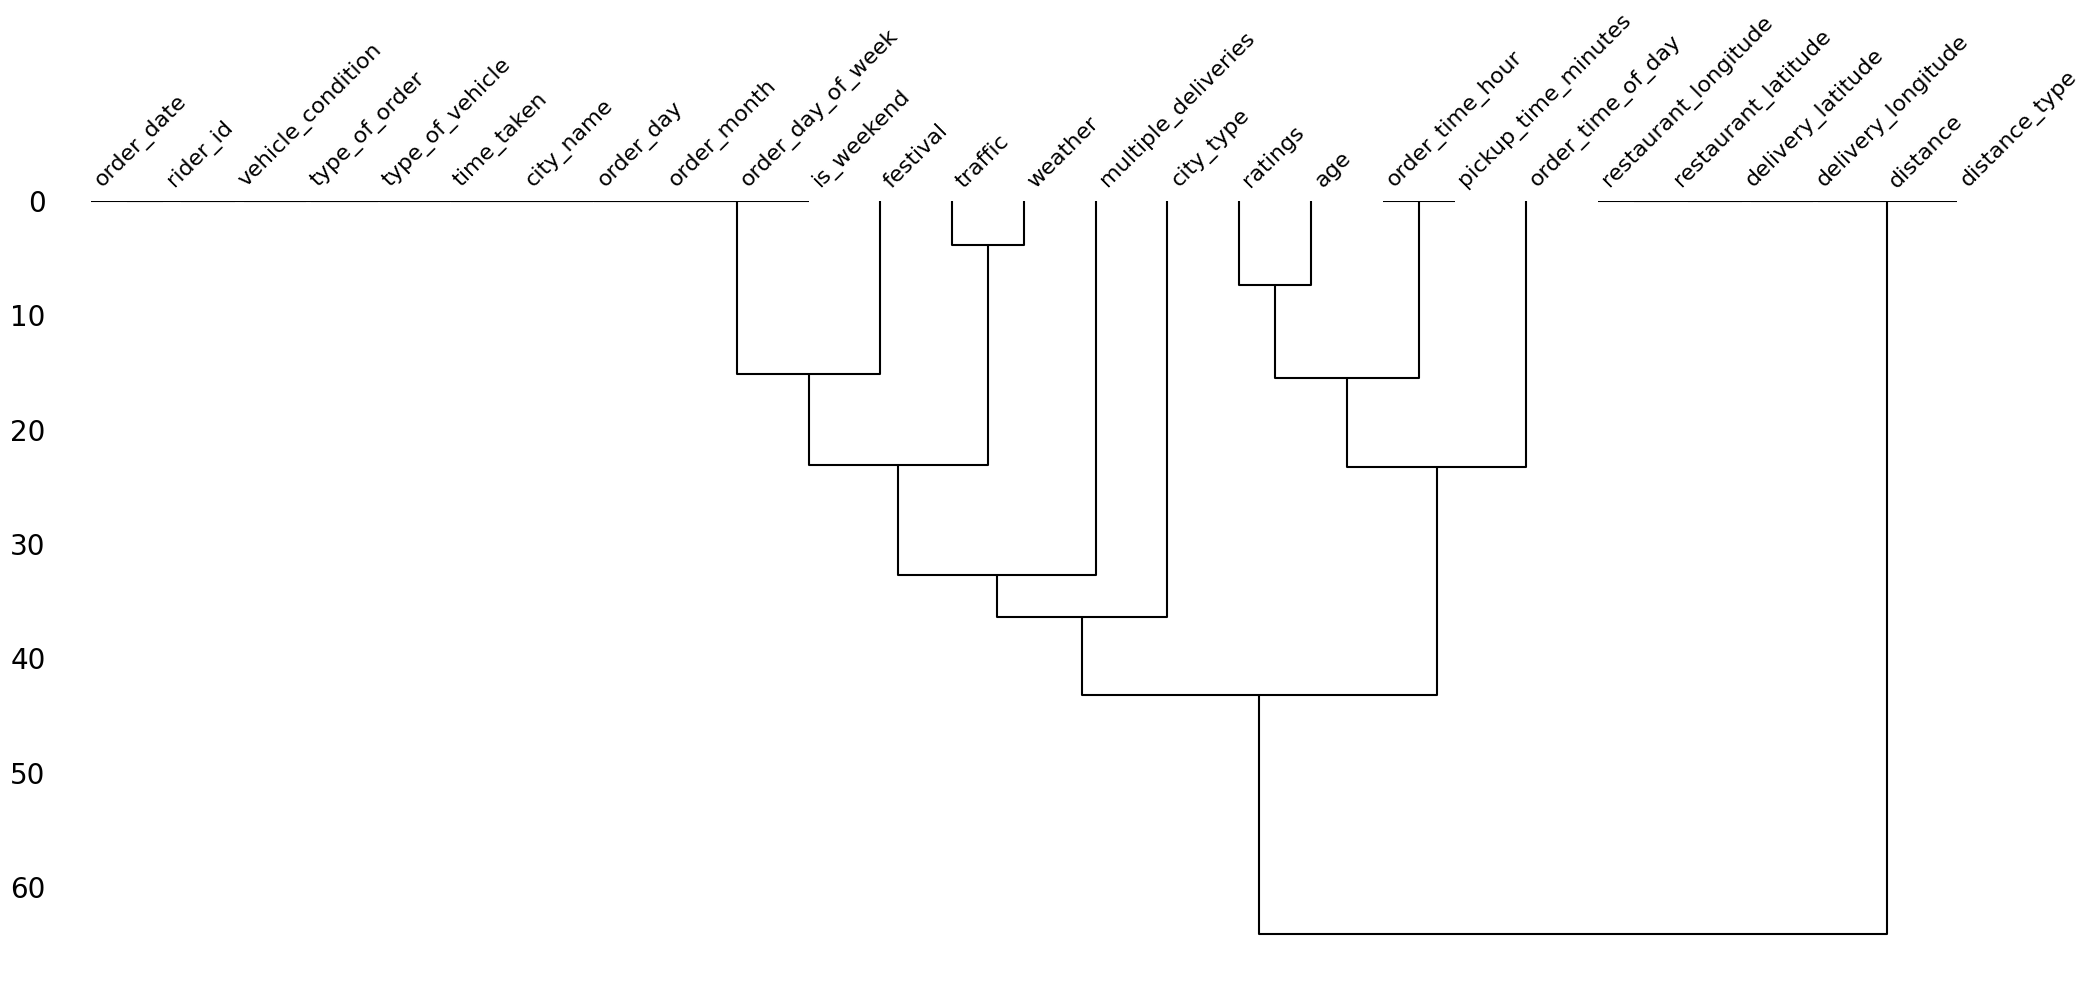

In [ ]:
msno.dendrogram(df_final)

Functions to perform analysis

In [ ]:
def numerical_analysis(dataframe,column_name,cat_col=None,bins="auto"):
  fig = plt.figure(figsize=(15,10))
  grid = GridSpec(nrows=2,ncols=2,figure=fig)

  ax1 = fig.add_subplot(grid[0,0])
  ax2 = fig.add_subplot(grid[0,1])
  ax3 = fig.add_subplot(grid[1,:])

  sns.kdeplot(data=dataframe,x=column_name,hue=cat_col,ax=ax1)

  sns.boxplot(data=dataframe,x=column_name,hue=cat_col,ax=ax2)

  sns.histplot(data=dataframe,x=column_name,bins=bins,hue=cat_col,kde=True,ax=ax3)
  plt.tight_layout()
  plt.show()

def numerical_categorical_analysis(dataframe,cat_column_1,num_column):
  fig,(ax1,ax2) = plt.subplots(2,2,figsize=(15,7.5))
  sns.barplot(data=dataframe,x=cat_column_1,y=num_column,ax=ax1[0])
  sns.boxplot(data=dataframe,x=cat_column_1,y=num_column,ax=ax1[1])
  sns.violinplot(data=dataframe,x=cat_column_1,y=num_column,ax=ax2[0])
  sns.stripplot(data=dataframe,x=cat_column_1,ax=ax2[1])
  plt.tight_layout()
  plt.show()

def categorical_analysis(dataframe,column_name):
  display(
      pd.DataFrame({
          "Count":(
          dataframe[column_name]
          .value_counts()),
          "Percentage":(
              dataframe[column_name]
              .value_counts(normalize=True)
              .mul(100)
              .round(2)
              .astype("str")
              .add("%")

          )

      })
  )
  print("*"* 50)
  #get unique categories
  unique_categories = dataframe[column_name].unique().tolist()
  number_of_categories = dataframe[column_name].nunique()
  print(f"The unique categories in {column_name} column are {unique_categories} ")
  print("*"*50)
  print(f"The number of categories in {column_name} column are {number_of_categories}")
  sns.countplot(data=dataframe,x=column_name)
  plt.xticks(rotation=45)
  plt.show()

def multivariate_analysis(dataframe,num_column,cat_column_1,cat_column_2):
  fig,(ax1,ax2) = plt.subplots(2,2,figsize=(15,7.5))
  sns.barplot(data=dataframe,x=cat_column_1,y=num_column,hue=cat_column_2,ax=ax1[0])
  sns.boxplot(data=dataframe,x=cat_column_1,y=num_column,gap=0.1,ax=ax1[1])
  sns.violinplot(data=dataframe,x=cat_column_1,gap=0.1,y=num_column,hue=cat_column_2,ax=ax2[0])
  sns.striplot(data=dataframe,x=cat_column_1,y=num_column,hue=cat_column_2,dodge=True,ax=ax2[1])
  plt.tight_layout()
  plt.show()

def chi_2_test(dataframe,col1,col2,alpha=0.05):
  data = {
      dataframe.loc[:,[col1,col2]]
      .dropna()
  }
  #create contingency table
  contingency_table = pd.crosstab(data[col1],data[col2])
  #perfrom chi-squared test
  _,p_val,_,_=chi2_contingency(contingency_table)
  print(p_val)
  if p_val <= alpha:
    print(f"Reject the null hypothesis .There is a significant relationship between {num_col} and {cat_col}")
  else:
    print(f"Fail to reject the null hypothesis.The data is normally distributed.")

def test_for_normality(dataframe,column_name,alpha=0.05):
  data=dataframe[column_name]
  print("jarque Bera test for normality")
  _, p_val = jarque_bera(data)
  print(p_val)
  if p_val<=alpha:
    print(f"Reject the null hypothesis .The data is not normally distributed")
  else:
    print(f"Fail to  reject the null hypothesis . The data is normally distributed.",end="\n\n")


In [ ]:
df_final.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

Time taken(target )

In [ ]:
#data type of column
df_final['time_taken'].dtype

dtype('int64')

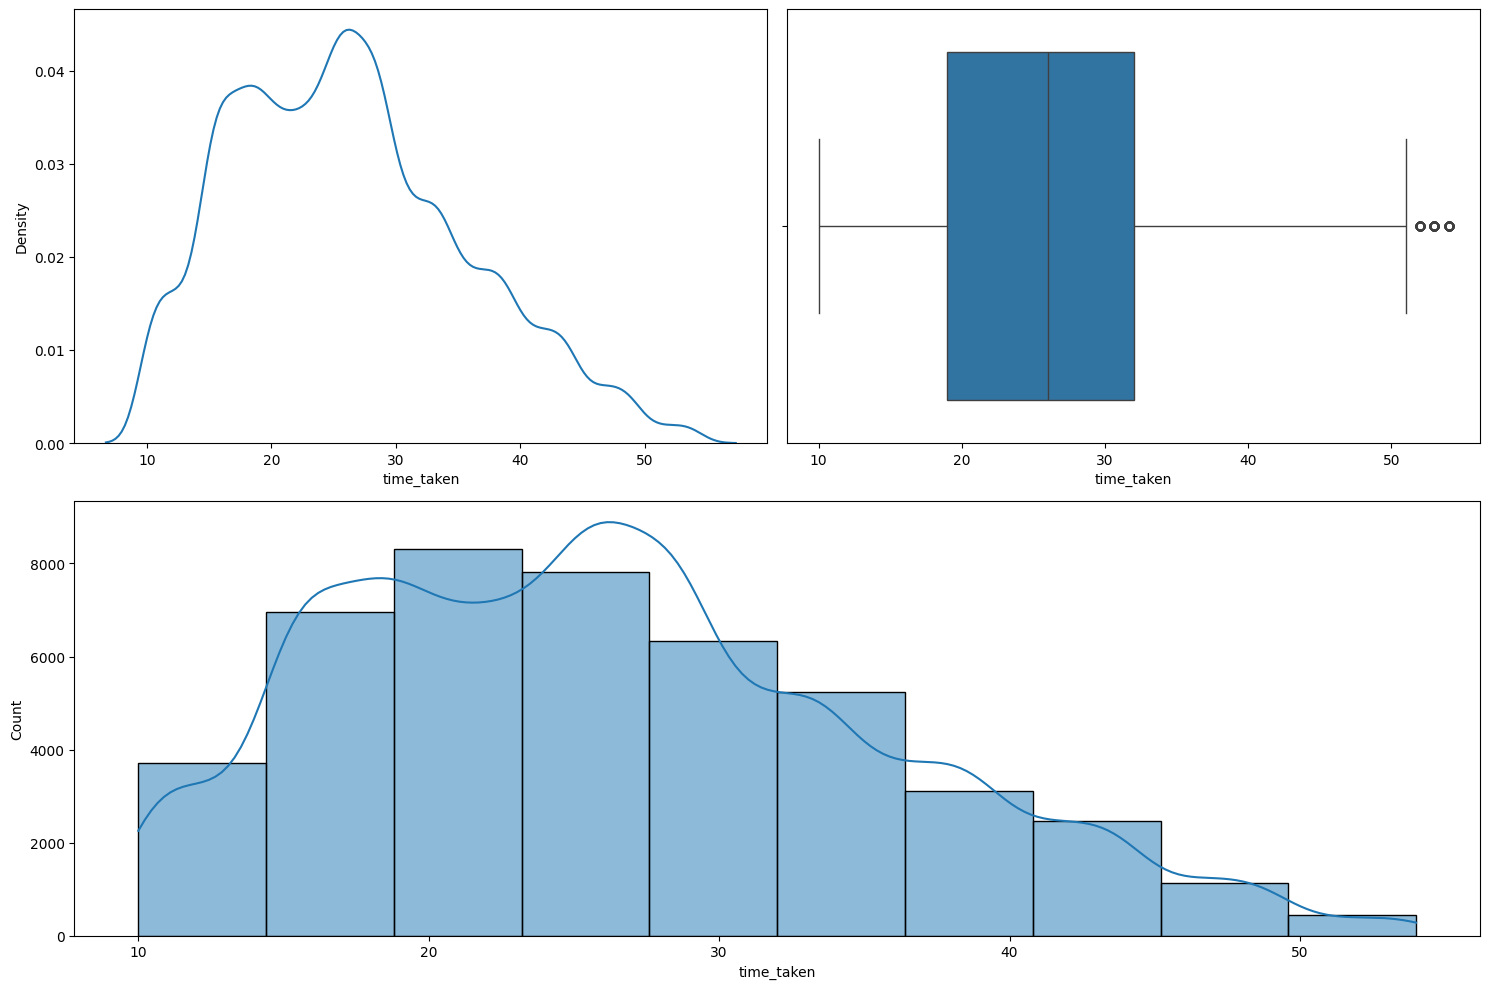

In [ ]:
#numerical analysis
numerical_analysis(df_final,'time_taken',bins=10)

**Obseravtions**


*  the target column is not fully continusosu in nature
*  two peaks one peak at 17 to 18 and other one 26 to 27
* it has some outliers, 50 min time is possibrl for delivery in certain rare cases




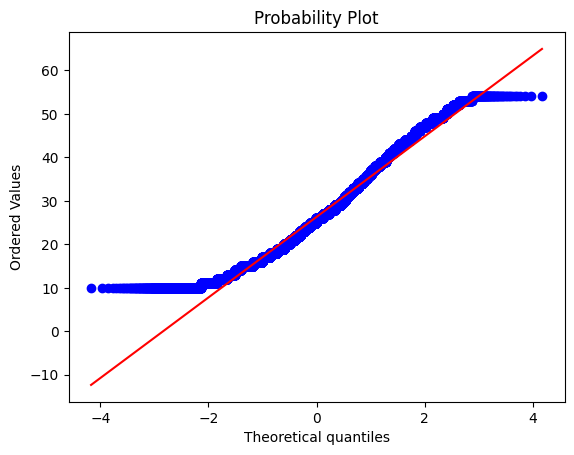

In [ ]:
#plot the qq plot of th e target
probplot(df_final['time_taken'],plot=plt)
plt.show()

In [ ]:
#test for normality
test_for_normality(df_final,'time_taken')

jarque Bera test for normality
0.0
Reject the null hypothesis .The data is not normally distributed


In [ ]:
#check out the rows where data is acting as outlier
target_25_per,target_75_per = np.percentile(df_final['time_taken'],[25,75])
iqr = target_75_per - target_25_per

upper_bound = target_75_per + (1.5 * iqr)

df_final.loc[(df_final['time_taken']>upper_bound),"traffic"].value_counts()

,count
traffic,
jam,241
high,24


In [ ]:
df_final.loc[(df_final['time_taken']>upper_bound),"weather"].value_counts()

,count
weather,
fog,57
sunny,51
windy,44
cloudy,44
stormy,37
sandstorms,32


In [ ]:
#avg distances
avg_distance = df_final.loc[:,"distance"].mean()
avg_distance_extreme = df_final.loc[(df_final['time_taken']>upper_bound),"distance"].mean()

print(avg_distance,avg_distance_extreme)

9.719296323199579 13.29215081388658


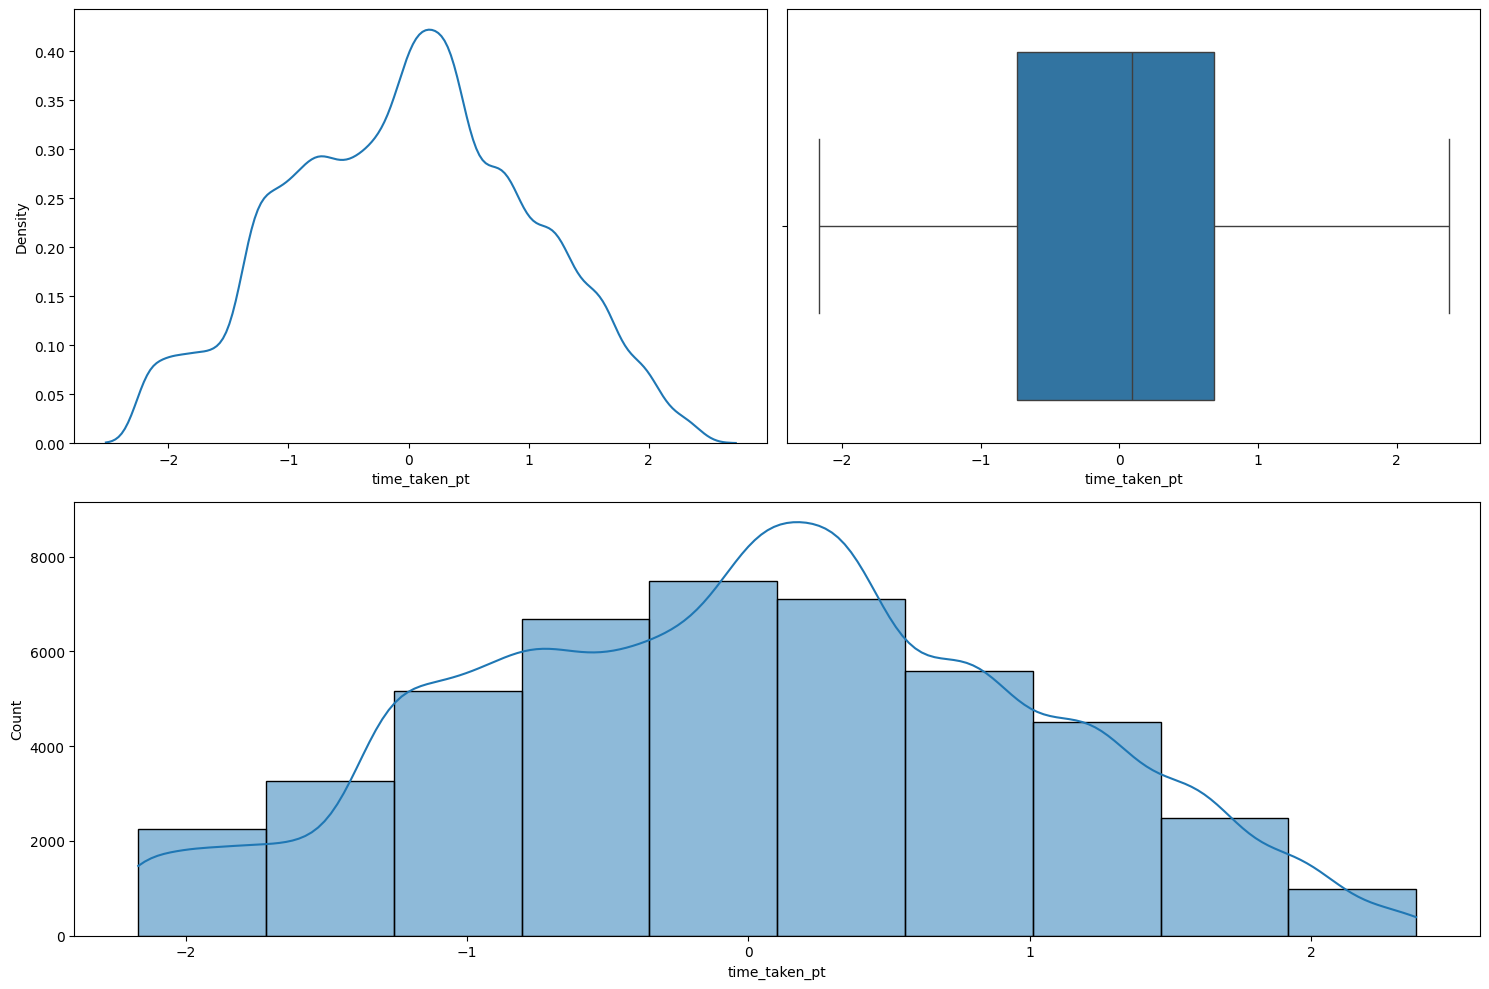

In [ ]:
#fix target column using transformation
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
df_final['time_taken_pt'] = pt.fit_transform(df_final[['time_taken']])
numerical_analysis(df_final,"time_taken_pt",bins=10)

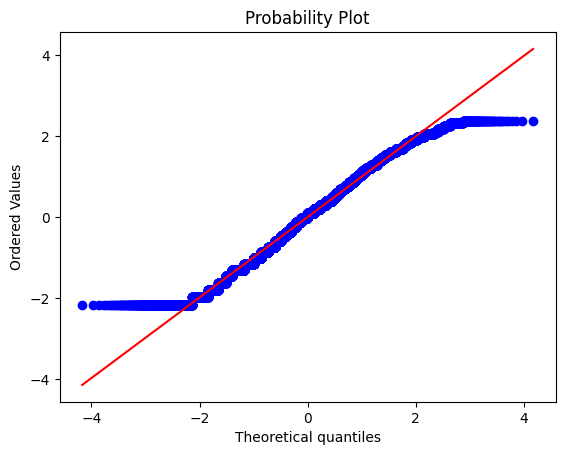

In [ ]:
#plot qq plot for the target afte the transformation
probplot(df_final['time_taken_pt'],plot=plt)
plt.show()

Rider id

In [ ]:
#datatype for rider id
df_final['rider_id'].dtype


dtype('O')

In [ ]:
df_final[['rider_id','age','ratings']]

,rider_id,age,ratings
0,INDORES13DEL02,37.0,4.9
1,BANGRES18DEL02,34.0,4.5
2,BANGRES19DEL01,23.0,4.4
3,COIMBRES13DEL02,38.0,4.7
4,CHENRES12DEL01,32.0,4.6
...,...,...,...
45497,JAPRES04DEL01,30.0,4.8
45498,AGRRES16DEL01,21.0,4.6
45499,CHENRES08DEL03,30.0,4.9
45500,COIMBRES11DEL01,20.0,4.7


In [ ]:
#sample of data
rider_id_group = df_final[['rider_id','age','ratings']].groupby('rider_id')
rider_id_group.head(5).sort_values('rider_id')

,rider_id,age,ratings
92,AGRRES010DEL01,34.0,4.7
7738,AGRRES010DEL01,21.0,4.7
4554,AGRRES010DEL01,38.0,4.7
12416,AGRRES010DEL01,34.0,4.5
13223,AGRRES010DEL01,39.0,4.4
...,...,...,...
861,VADRES20DEL03,35.0,4.8
9792,VADRES20DEL03,30.0,4.6
9753,VADRES20DEL03,38.0,4.8
5094,VADRES20DEL03,35.0,4.9


In [ ]:
#check for duplicates
df_final[["rider_id","age","ratings"]].dropna().duplicated(keep=False).sum()

np.int64(10155)

In [ ]:
#filter for duplicates
(
    df_final
     .loc[(df_final[["rider_id","age","ratings"]].duplicated(keep=False)),['rider_id','age','ratings']]
    .dropna()
    .sort_values(["rider_id"])
)

,rider_id,age,ratings
18533,AGRRES03DEL02,24.0,4.9
40285,AGRRES03DEL02,24.0,4.9
28473,AGRRES03DEL03,30.0,4.7
26275,AGRRES03DEL03,30.0,4.7
36131,AGRRES06DEL02,36.0,4.9
...,...,...,...
12742,VADRES20DEL02,28.0,4.5
5094,VADRES20DEL03,35.0,4.9
17963,VADRES20DEL03,35.0,4.9
21957,VADRES20DEL03,37.0,4.9


Not useful for our analysis

**Age**

In [ ]:
#data type of age column
df_final['age'].dtype

dtype('float64')

In [ ]:
#statistical summary
df_final['age'].describe()

,age
count,43648.000000
mean,29.555008
std,5.761482
min,20.000000
25%,25.000000
50%,30.000000
75%,35.000000
max,39.000000


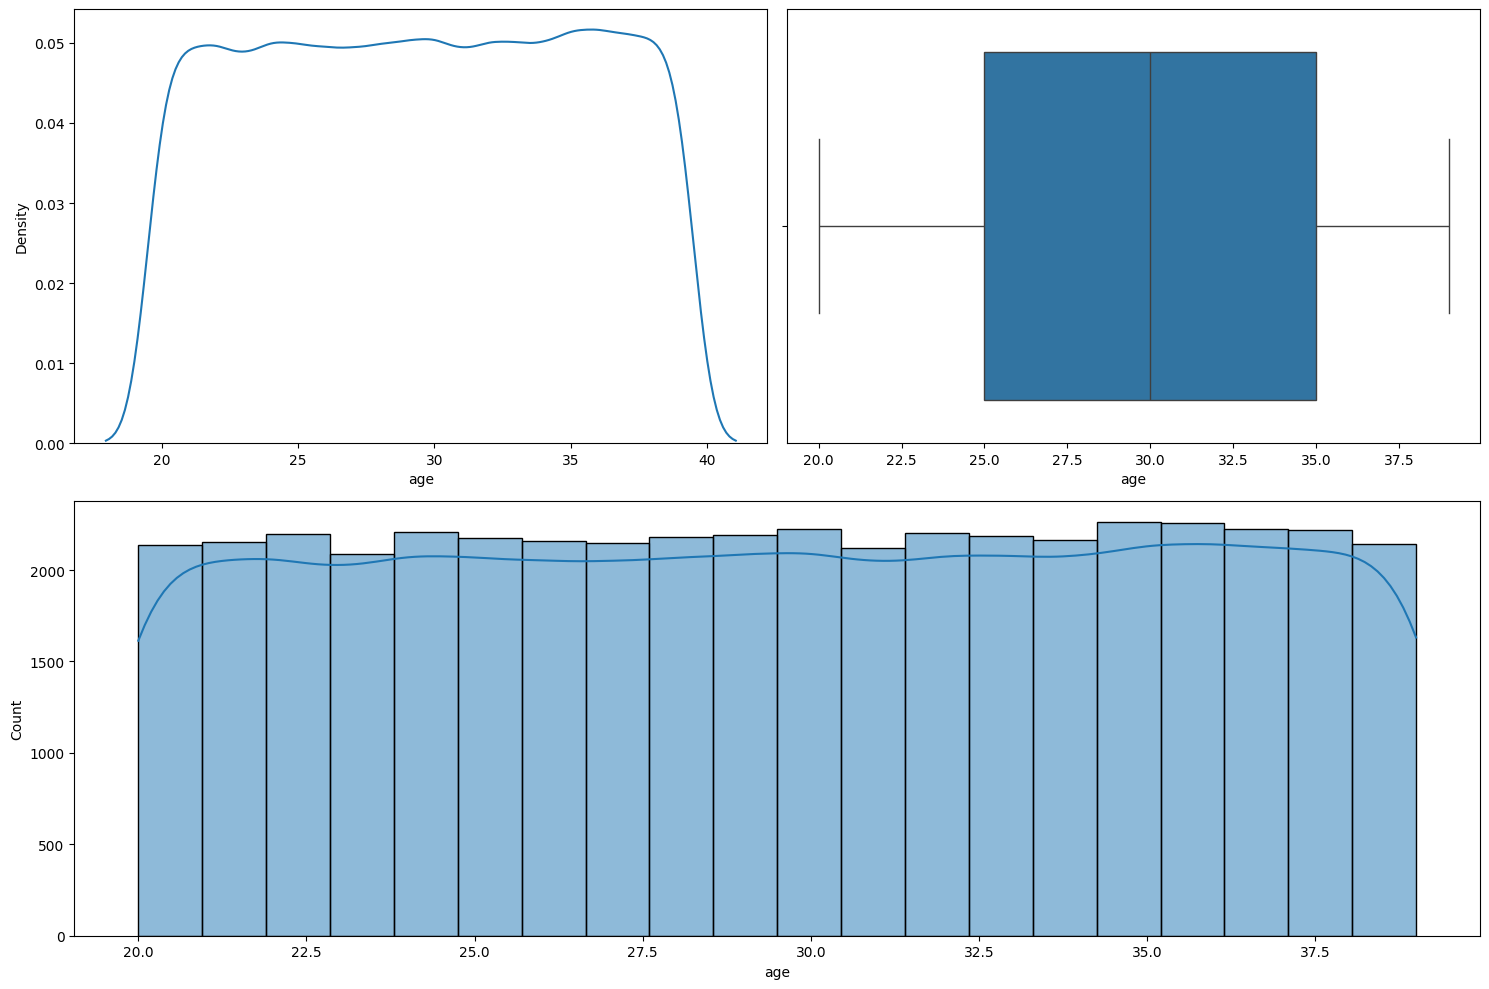

In [ ]:
#numerical analysis for age
numerical_analysis(df_final,'age',bins=20)

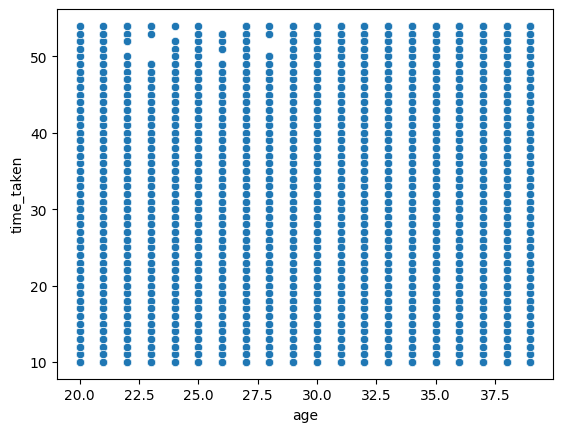

In [ ]:
#relationship between target and age
sns.scatterplot(data=df_final,x='age',y='time_taken')
plt.show()

Age of the rider does not show any impace on time taken to deliever

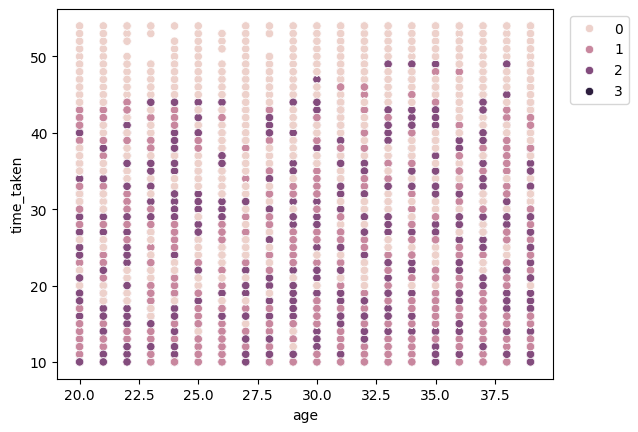

In [ ]:
sns.scatterplot(data=df_final,x='age',y='time_taken',hue='vehicle_condition')
plt.legend(bbox_to_anchor=(1.02,1),loc=2)
plt.show()

<Axes: xlabel='type_of_vehicle', ylabel='age'>

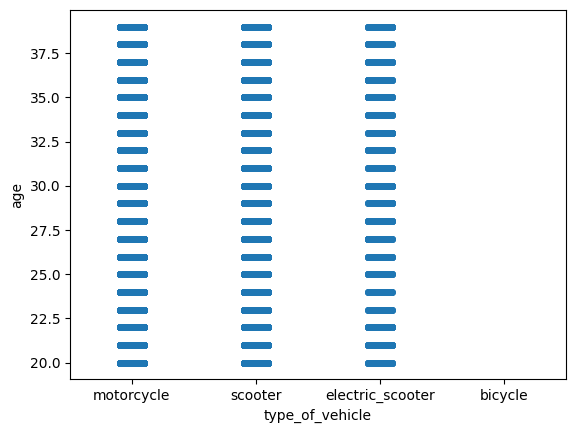

In [ ]:
#preferences of vehicle type based on age
sns.stripplot(df_final,x='type_of_vehicle',y='age')

Ratings

In [ ]:
#data type of rating column
df_final['ratings'].dtype

dtype('float64')

In [ ]:
#statistical summary
df_final['ratings'].describe()

,ratings
count,43594.000000
mean,4.635287
std,0.313827
min,2.500000
25%,4.500000
50%,4.700000
75%,4.900000
max,5.000000


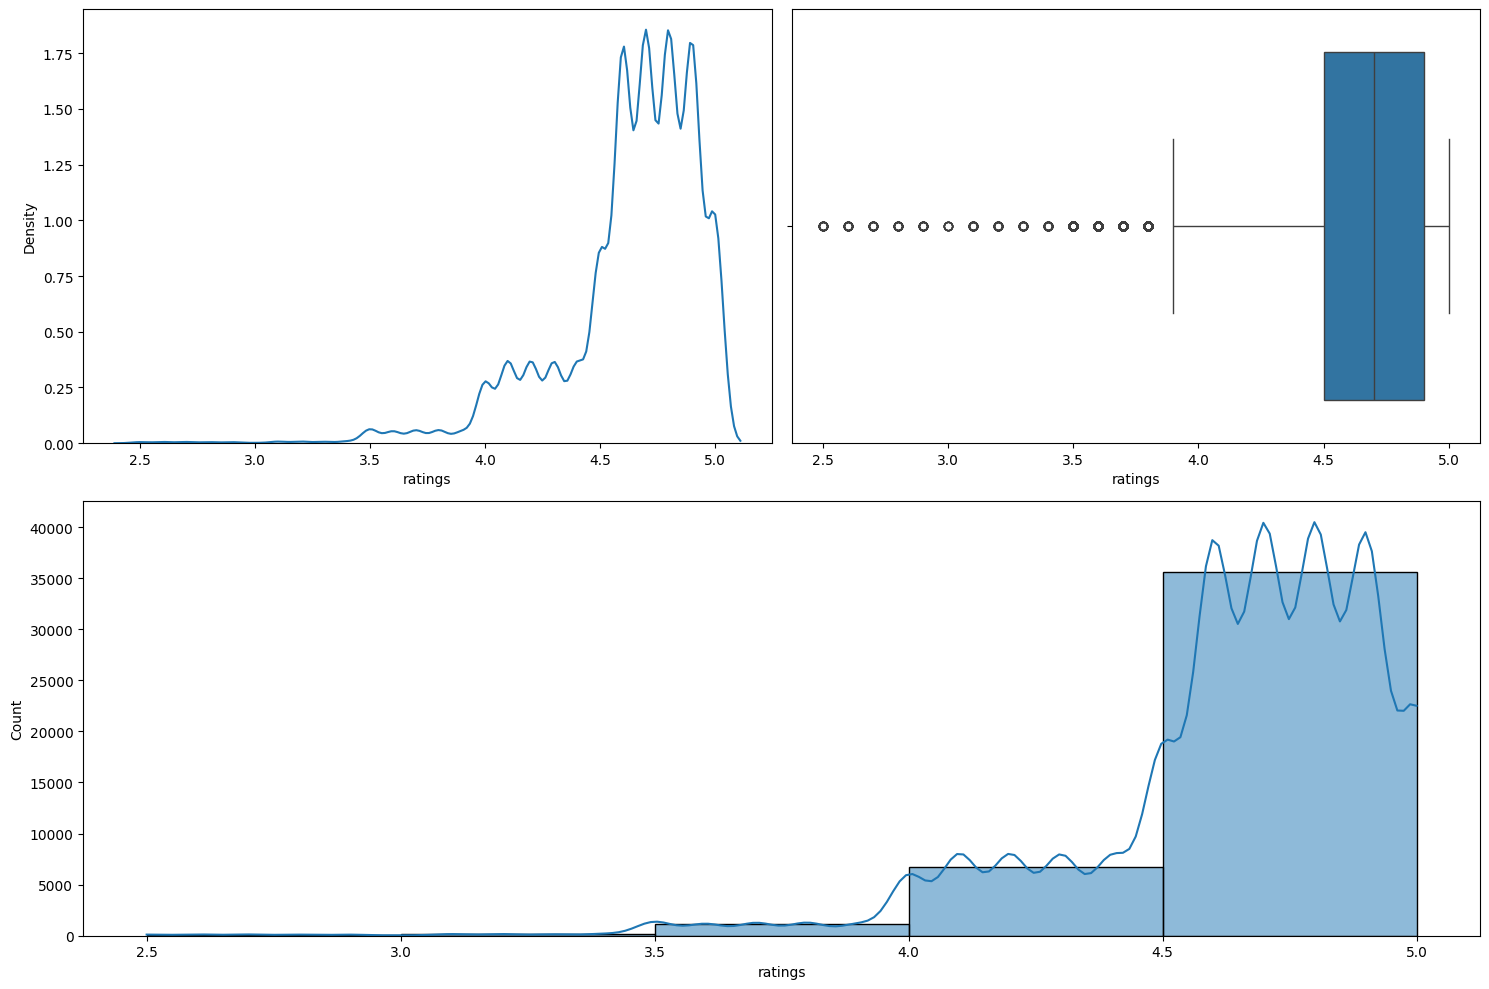

In [ ]:
#numerical analysis
numerical_analysis(df_final,'ratings',bins=5)

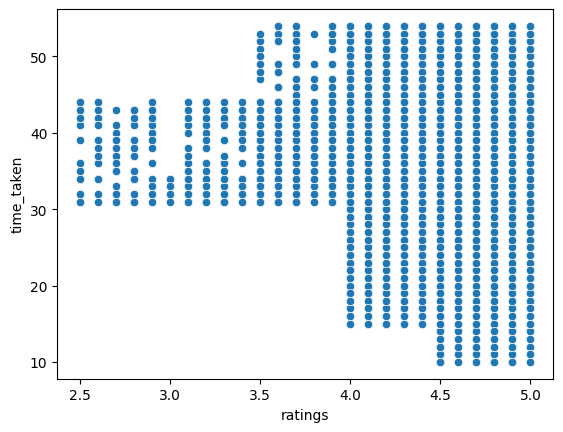

In [ ]:
#does ratings affect delivery time
sns.scatterplot(data=df_final,x='ratings',y='time_taken')
plt.show()

It seems like riders with more ratings get more orders

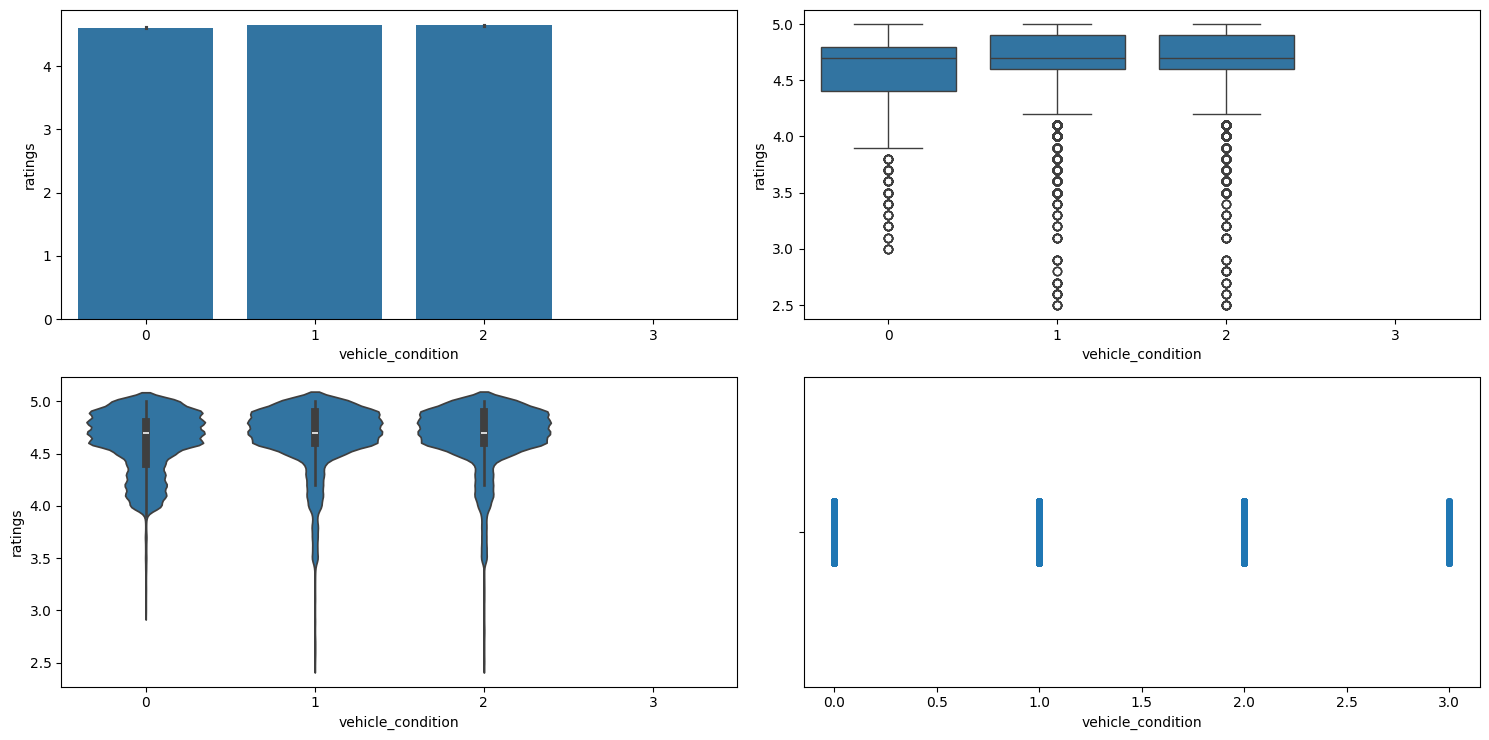

In [ ]:
#does ratingss get affected by vehicle type
numerical_categorical_analysis(df_final,'vehicle_condition','ratings')

The more worst the vehicle the more lower the rating , category 3 is not avaliable and has no data there are nan values

In [ ]:
(
    df_final[['ratings','vehicle_condition']]
    .loc[df_final['vehicle_condition']==3,'ratings']
    .value_counts(dropna=False)
)

,count
ratings,
NaN,429


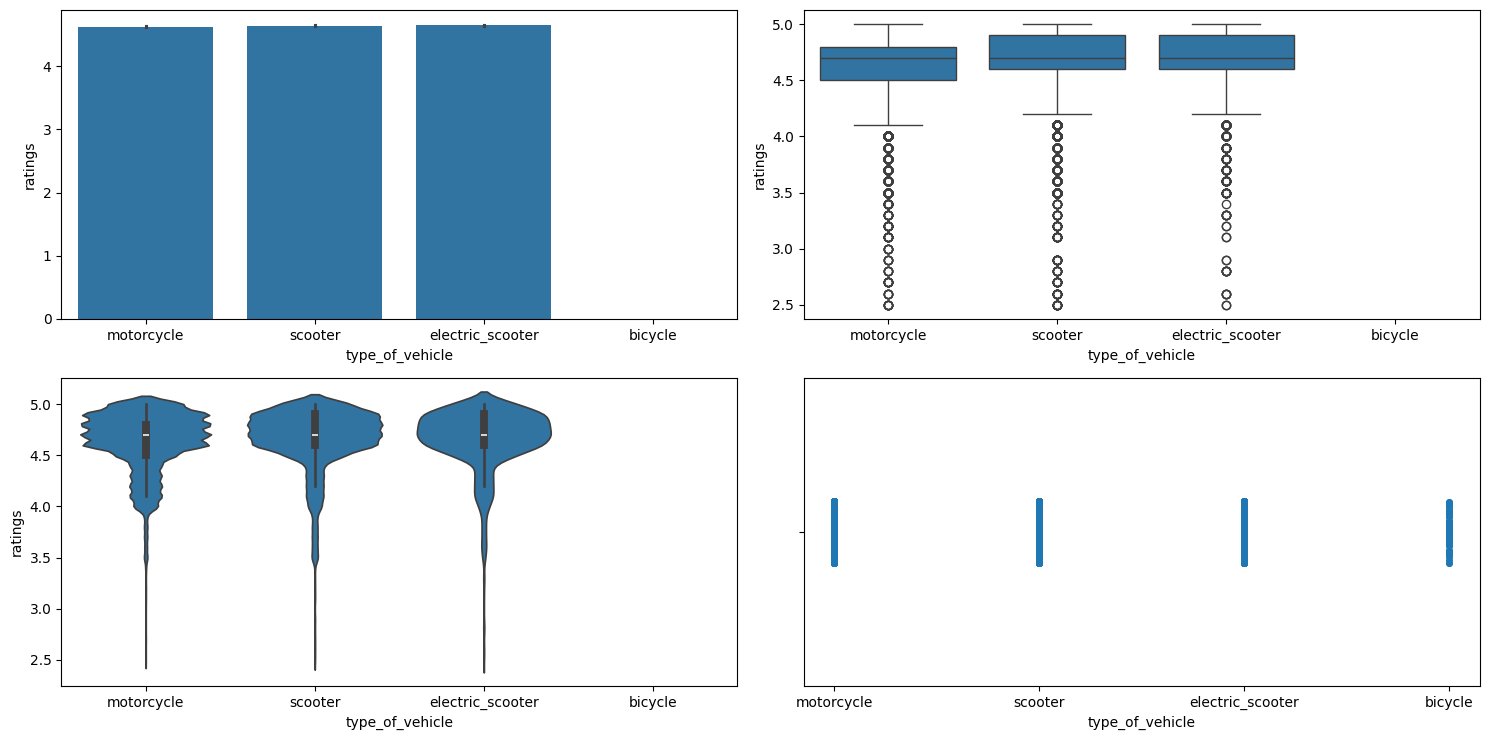

In [ ]:
#does type of vehicle affect ratings
numerical_categorical_analysis(df_final,'type_of_vehicle','ratings')

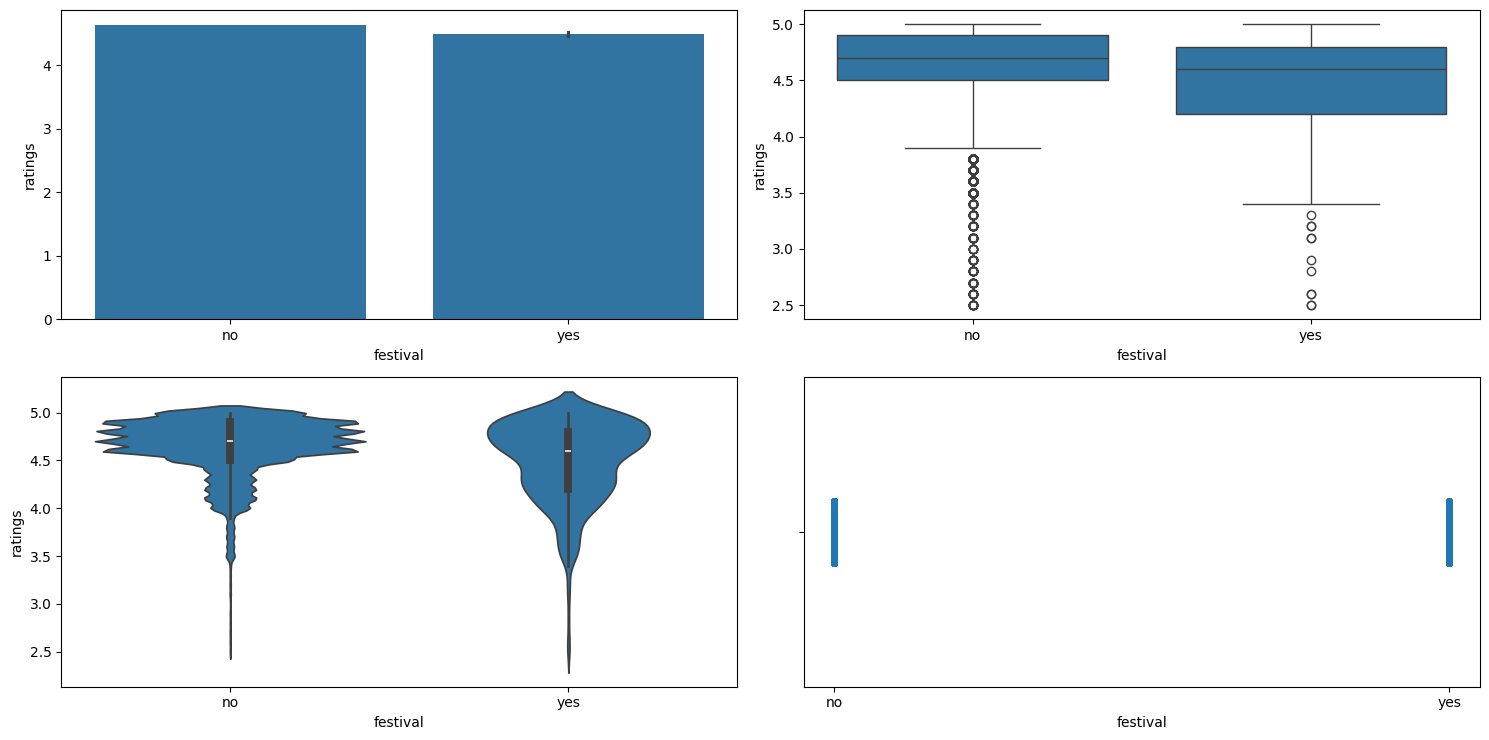

In [ ]:
#festival and rider ratings
numerical_categorical_analysis(df_final,'festival','ratings')

**Location Based Featues**

In [ ]:
df_final.columns[3:7].tolist()+['city_name']

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'city_name']

In [ ]:
#location_subset
location_subset = df_final.loc[:,df_final.columns[3:7].tolist()+['city_name']]
location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city_name
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
45497,26.902328,75.794257,26.912328,75.804257,JAP
45498,NaN,NaN,NaN,NaN,AGR
45499,13.022394,80.242439,13.052394,80.272439,CHEN
45500,11.001753,76.986241,11.041753,77.026241,COIMB


In [ ]:
location_subset.dtypes

,0
restaurant_latitude,float64
restaurant_longitude,float64
delivery_latitude,float64
delivery_longitude,float64
city_name,object


In [ ]:
#drop missing values
location_subset.dropna(inplace=True)
location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city_name
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
45496,23.371292,85.327872,23.481292,85.437872,RANCHI
45497,26.902328,75.794257,26.912328,75.804257,JAP
45499,13.022394,80.242439,13.052394,80.272439,CHEN
45500,11.001753,76.986241,11.041753,77.026241,COIMB


In [ ]:
#plot the deliveries on map
delivery_df = pd.DataFrame({

    'latitude':location_subset['delivery_latitude'],
    'longitude':location_subset['delivery_longitude'],
    'city_name':location_subset['city_name']
})

#create a map using plotly scatter_mapbox
fig.update_layout(
    mapbo_style="carto-positron",
    mapbox_center={"lat":20.5937,"lon":78.9629}, #centered over india
    mapbox_zoom = 3,

)

#show the plot
fig.show()





NameError: name 'fig' is not defined

**Order Date**

In [ ]:
df_final.columns

In [ ]:
df_final.filter(like="order")

In [ ]:
#order date columns
order_date_subset = df_final.loc[:,["order_date","order_day","order_month","order_day_of_week","is_weekend","festival"]]
order_date_subset

In [ ]:
#analysis b/w day of week and target
numerical_categorical_analysis(df_final,"order_day_of_week","time_taken")

In [ ]:
#does having a weekend affects target
numerical_categorical_analysis(df_final,"is_weekend","time_taken")

**observations**


1.   if there is festival it takes longer time than usual

2.   avg time varies when there is a festival



In [ ]:
#do festival affect the traffic
chi_2_test(df_final,"festival","traffic")

In [ ]:
df_final.pivot_table(index="traffic",columns="festival",values="time_taken",aggfunc="mean")

In [ ]:
#does a weekend and festival combined have an effect on delivery ties
multivariate_analysis(df_final,"time_taken","is_weekend","festival")

**Order Time**

In [ ]:
df_final.columns

In [ ]:
#time related columns
time_subset = df_final.loc[:,["order_time_hour","order_time_of_day","pickup_time_minutes"]]
time_subset

In [ ]:
#does time of the order day aggect the deliver time
numerical_categorical_analysis(df_final,"order_time_of_day","time_taken")

In [ ]:
#relationship between time of the day and traffic
chi_2_test(df_final,"order_time_of_day","traffic")

In [ ]:
#anova test
anova_test(df_final,"time_taken","order_time_of_day")

In [ ]:
#top 5 time hours in which customer order the most
df_final['order_time_hour'].value_counts().head(5)

In [ ]:
#can delivery time be affected by both time of day and traffic
multivariate_analysis(df_final,"time_taken","order_time_of_day","traffic")

In [ ]:
#categorical analysis an order_time_hour
categorical_analysis(df_final,"order_time_hour")

In [ ]:
#categorical analysis on time of day
categorical_analysis(df_final,"order_time_of_day")

**Pickup time**

In [ ]:
df_final['pickup_time_minutes'].dtype

In [ ]:
#relationship b/w pickup time and delivery time
sns.scatterplot(df-final,x="pickup_time_minutes",y="time_taken")
plt.show()

**Pickup the column to ordinal categorical column**

In [ ]:
#pickup time categorical analysis
categorical_analysis(df_final,"pickup_time_minutes")

In [ ]:
#does pickup time have an effect on delivery time
numerical_categorical_analysis(df_final,"pickup_time_minutes","time_taken")

In [ ]:
#hypothesis testing to prove point
anova_test(df_final,"time_taken","pickup_time_minutes")


**Traffic**

In [ ]:
#datatype of traffic column
df_final['traffic'].dtype

In [ ]:
#categorical analysis on traffic
categorical_analysis(df_final,"traffic")

In [ ]:
#does traffic depend on type of city
chi_2_test(df_final,"traffic","city_type")

In [ ]:
#does traffic affects the delivery times
numerical_categorical_analysis(df_final,'traffic','time_taken')

In [ ]:
#hypothesis test on does traffic affects the delivery time
anova_test(df_final,"time_taken","traffic")

In [ ]:
##are some vehicle types more suitable in traffic than hours
multivariate_analysis(df_final,"time_taken","traffic","type_of_vehicles")

In [ ]:
#does vehicle condition in traffic situatuons affects the delivery times
multivariate_analysis(df_final,"time_taken","traffic","vehicle_condition")

good vehicles are preferres most in longer delivery times in festival

In [ ]:
multivariate_analysis(df_final,"time_taken","festival","vehicle_condition")

**Mutliple deliveries**

In [ ]:
#does multiple deliveries  affect delivery times
numerical_categorical_analysis(df_final,'multiple_deliveries','time_taken')

In [ ]:
#hypothesie test
anova_test(df_final,"time_taken","multiple_deliveries")

In [ ]:
#do multiple deliveries are of longer distance
numerical_categorical_analysis(df_final,"multiple_deliveries","distance")

**Weather**

In [ ]:
#data type of weather column
df_final['weather'].dtype

In [ ]:
#categorical analysis on type of weather
categorical_analysis(df_final,"weather")

In [ ]:
#does waether effect delivery time
numerical_categorical_analysis(df_final,"weather","time_taken")

In [ ]:
#hypothesis test
anova_test(df_final,"time_taken","weather")

In [ ]:
#does weather affects traffic
chi_2_test(df_final,"weather","traffic")

In [ ]:
#delivery times based on weather and traffic
multivariate_analysis(df_final,"time_taken","weather","traffic")

In [ ]:
#pivot table
df_final.pivot_table(index="weather",columns="traffic",values="time_taken",aggfunc="mean")

**Vehicle-Condition Type**

In [ ]:
#categorical analysis on vehicle condition
categorical_analysis(df_final,"vehicle_condition")

In [ ]:
#does vehicle condition affect delivery times
numerical_categorical_analysis(df_final,"vehicle_condition","time_taken")

In [ ]:
#anova test
anova_test(df_final,"time_taken","vehicle_condition")

In [ ]:
#analysis on vehicle condition
categorical_analysis(df_final,"type_of_vehicle")

In [ ]:
#does the type of vehicle affect f=delivery time
numerical_categorical_analysis(df_final,"type_of_vehicle","time_taken")

In [ ]:
#vehcile condition type
multivariate_analysis(df_final,"time_taken","vehicle_condition","type_of_vehicle")

In [ ]:
#is their any relation between vehicle type and condition
chi_2_test(df_final,"type_of_vehicle","vehicle_condition")

**Type of order**

In [ ]:
#type of order type
df_final['type_of_order'].dtype

In [ ]:
#analysis of type of order
categorical_analysis(df_final,"type_of_order")

In [ ]:
#does the order the efeect the delivery times
numerical_categorical_analysis(df_final,"type_of_order","time_taken")

In [ ]:
#hypothesie test
anova_test(df_final,"time_taken","type_of_order")

In [ ]:
#contingencytable
pd.crosstab(df_final['type_of_order'],df_final['is_weekend'])

In [ ]:
#does type of order have an effect over pickup time
chi_2_test(df_final,"pickup_time_minutes","type_of_order")

In [ ]:
#does order type have an ffect over ratings
numerical_categorical_analysis(df_final,"type_of_order","ratings")

In [ ]:
#is their any relationship b/w weekends and type of order
chi_2_test(df_final,"is_weekend","type_of_order")

**City Name**

In [ ]:
#categorical analysi on city name
categorical_analysis(df_final,"city_name")

In [ ]:
#does a city effect delivery time
numerical_categorical_analysis(df_final,"city_name","time_taken")

In [ ]:
#categorical analysis on city type
categorical_analysis(df_final,"city_type")

In [ ]:
#does city affect delivery time
numerical_categorical_analysis(df_final,"city_type","time_taken")

In [ ]:
#hypothesis test
anova_test(df_final,"time_taken","city_type")

In [ ]:
#does city effect rider rating
numerical_categorical_analysis(df_final,"city_type","ratings")

In [ ]:
#city type,type of vehicle and delivery time analysis
multivariate_analysis(df_final,"time_taken","city_type","type_of_vehicle")

**Distance**

In [ ]:
#numerical analysis of distance
numerical_analysis(df_final,"distance",bins=10)

In [ ]:
#relationship b/w distance n ad delivery times
sns.scatterplot(df_final,x="distance",y="time_taken")
plt.show()

In [ ]:
#corr
df_final[['distance','time_taken']].corr()

In [ ]:
#vehicle type and distance nalysis
numerical_categorical_analysis(df_final,"type_of_vehicle","distance")

In [ ]:
#do riders covers most ditance in festival
numerical_categorical_analysis(df_final,"distance","festival")

In [ ]:
#distance and city type
numerical_categorical_analysis(df_final,"distance","city_type")

In [ ]:
#new feature based on distance
df_final = df_final.assign(
    distance_type = pd.cut(df_final['distance'],bins=[0,5,10,15,25],
                           right=False,labels=['short','medium','long','very_long'])
)

In [ ]:
df_final

In [ ]:
#does delivery type affect delivery times
numerical_categorical_analysis(df_final,"distance_type","time_taken")

In [ ]:
#delivery times basd on distance an dtraffic
multivariate_analysis(df_final,"time_taken","distance_type","traffic")